In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os
import dataset
from matplotlib.patches import Patch
import torch
import torch.nn as nn
from collections import OrderedDict
import sys
sys.path.append(os.path.join(os.getcwd(), "models"))
from models.unet import *
from models.majority_classifier import *
from matplotlib.colors import ListedColormap, BoundaryNorm
from utilities.utils import plot_confusion_matrix, compute_confusion_matrix
from torchview import draw_graph

In [3]:
ds = dataset.DFC18(split="test", normalize=True, standardize=False)

Loaded 17409 samples from test set


**Prediction Visuals**

In [4]:
def visualize_rgb_prediction_label(patch, patch_stand=None, model=None, model_is_majority=False, model_is_stand=False, confusion=False):
    class_info = ds.class_info

    # Create a figure with three subplots
    fig, ax = plt.subplots(1, 3, figsize=(14, 6))

    # Plot the patch
    image = patch['image']
    ax[0].imshow(np.transpose(image, (1, 2, 0)))  # Convert to HxWxC
    ax[0].set_title('Image')
    ax[0].axis('off')

    # Create a custom colormap for the labels
    colors = [tuple(np.array(color) / 255.0) for _, color in class_info.values()]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(boundaries=np.arange(len(class_info) + 1), ncolors=len(colors))

    # Get prediction
    if model is not None:
        model.eval()
        with torch.no_grad():
            if model_is_stand:
                input_tensor = torch.tensor(patch_stand['image']).unsqueeze(0).to(next(model.parameters()).device)
            else:
                input_tensor = torch.tensor(patch['image']).unsqueeze(0).to(next(model.parameters()).device)
            output = model(input_tensor)

            if model_is_majority:
                if output.dim() == 4:
                    output = output.squeeze(-1).squeeze(-1)
                predicted_class = output.argmax(dim=1).item()
                H, W = patch['label'].shape
                pred = np.full((H, W), predicted_class, dtype=np.int32)
            else:
                output = torch.argmax(output, dim=1)
                pred = output.squeeze(0).cpu().numpy().astype(np.int32)
                print(np.unique(pred))
    else:
        pred = np.zeros_like(patch['label'], dtype=np.int32)  # fallback

    # class_id → RGB color
    id_to_color = np.zeros((max(class_info.keys()) + 1, 3), dtype=np.uint8)
    for class_id, (_, color) in class_info.items():
        id_to_color[class_id] = color

    # Map prediction to RGB
    pred_rgb = id_to_color[pred]  # (H, W, 3)

    # Mask unclassified pixels (set them to black)
    #pred_rgb[patch['label'] == 0] = [0, 0, 0] ### COMMENT TO TURN OFF MASKING ###

    # Plot masked prediction
    ax[1].imshow(pred_rgb)
    ax[1].set_title('Prediction')
    ax[1].axis('off')

    # Show ground truth
    id_to_color = np.zeros((max(class_info.keys()) + 1, 3), dtype=np.uint8)
    for class_id, (_, color) in class_info.items():
        id_to_color[class_id] = color

    label_rgb = id_to_color[patch['label']]
    ax[2].imshow(label_rgb)
    ax[2].set_title('Ground Truth')
    ax[2].axis('off')

    # Create legend — no "no prediction" label
    legend_elements = [
        Patch(facecolor=tuple(np.array(color)/255.0), edgecolor='black', label=name)
        for name, color in class_info.values()
    ]
    plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Classes")

    plt.tight_layout()
    plt.show()

    if confusion:
        true_mask = patch['label']
        valid_mask = true_mask != 0

        y_true = true_mask[valid_mask]
        y_pred = pred[valid_mask]

        cm = compute_confusion_matrix(y_true, y_pred, 21)

        # Filter class_info to exclude class 0, keep dict structure
        filtered_class_info = {i: v for i, v in class_info.items() if i != 0}

        plot_confusion_matrix(cm, filtered_class_info)


(3, 256, 256)
UH_NAD83_271460_3289689_x0_y2560
[ 0  9 11]
11
[ 5  8  9 10 11 13 19 20]


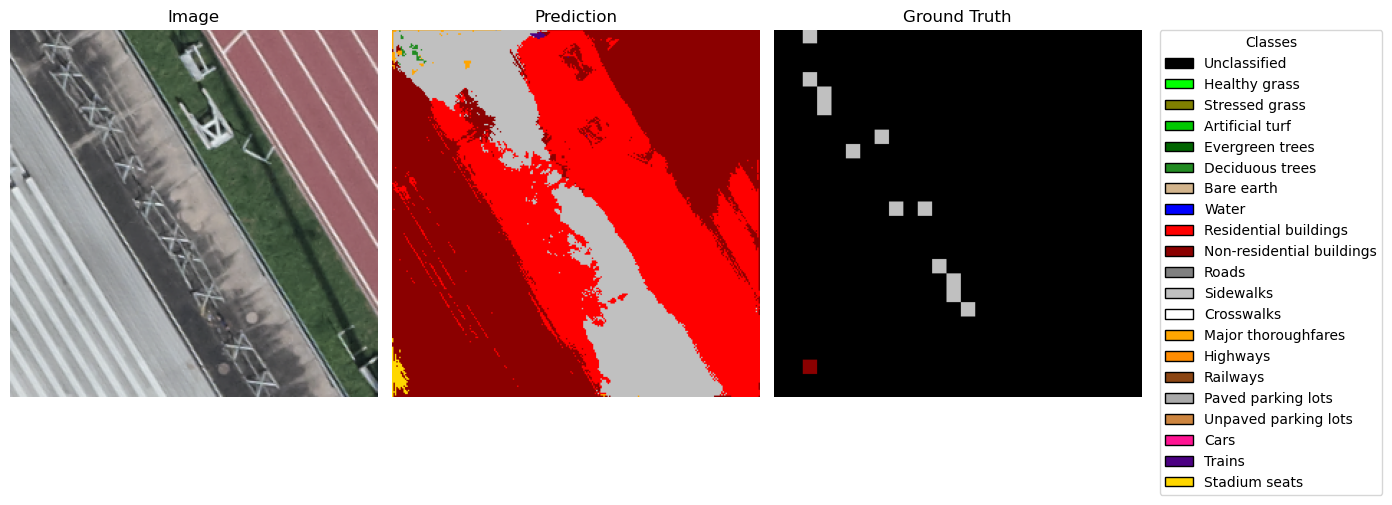

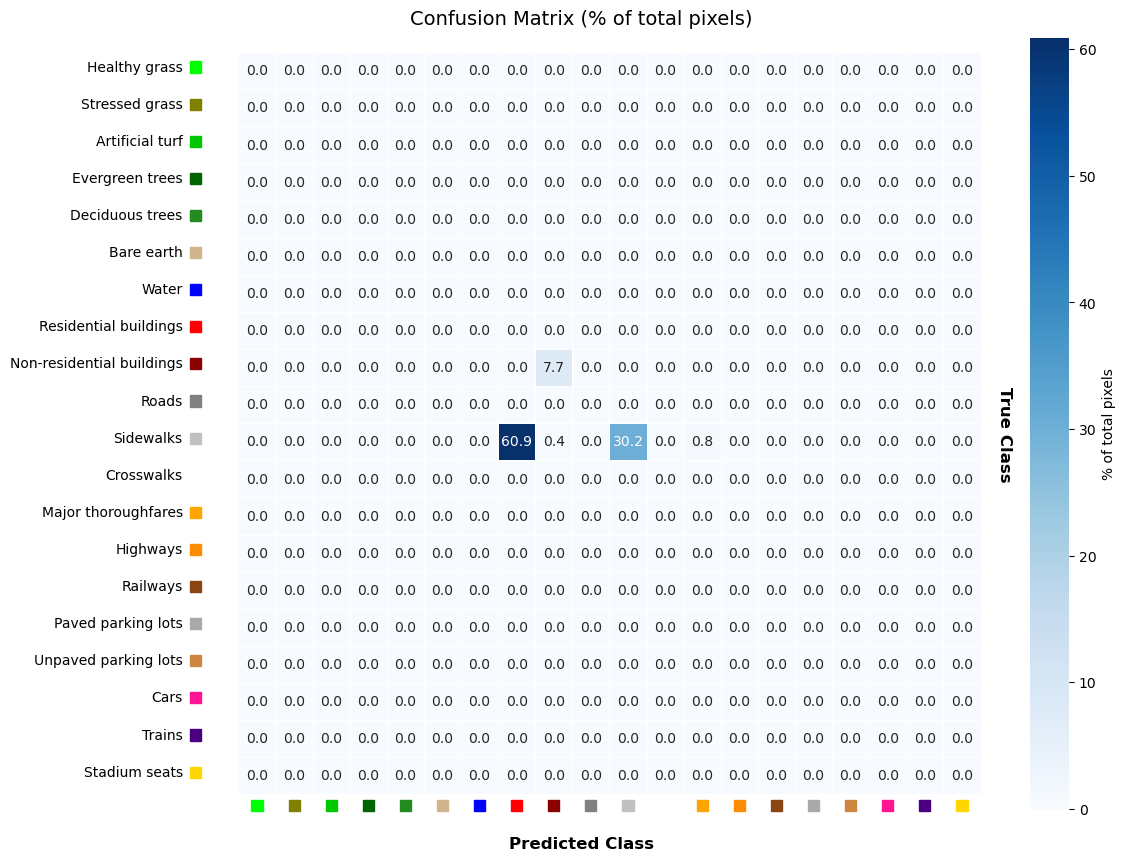

"\nmodel_encoder_majority_path = 'trained_models/majority_s2_base-1.pth'\nmodel_encoder_majority = AutoSizedMajorityClassifier(\n    encoder=model.encoder,\n    feature_level=-1,   # bottleneck output -1, or -2 for previous, etc.\n    target_head_params=500\n)\nmodel_encoder_majority.load_state_dict(torch.load(model_encoder_majority_path))\n\nvisualize_rgb_prediction_label(patch, patch_stand=patch_stand, model=model_encoder_majority, model_is_stand=True, model_is_majority=True)\n"

In [13]:
patch_index = 12 # 25,306,500 bad label example (city); 550,553 cropland dots warum? (wie ist ground truth entstanden); train 720 ähnlich weird; train 3000,2000,2500!!! 
#12 TROLL LABE?????
patch = ds.__getitem__(patch_index) 
print(patch["image"].shape)
print(patch["id"])
print(np.unique(patch["label"]))
print(patch["majority_class"])

#patch_stand = ds_stand.__getitem__(patch_index) 
model_path = 'trained_models/segmentation/unet_base.pth' 
model = UNetBase(n_channels=3)  # n_channels based on model

model.load_state_dict(torch.load(model_path))

visualize_rgb_prediction_label(patch, patch_stand=None, model=model, model_is_stand=False, confusion=True) 
"""
model_encoder_majority_path = 'trained_models/majority_s2_base-1.pth'
model_encoder_majority = AutoSizedMajorityClassifier(
    encoder=model.encoder,
    feature_level=-1,   # bottleneck output -1, or -2 for previous, etc.
    target_head_params=500
)
model_encoder_majority.load_state_dict(torch.load(model_encoder_majority_path))

visualize_rgb_prediction_label(patch, patch_stand=patch_stand, model=model_encoder_majority, model_is_stand=True, model_is_majority=True)
"""

In [6]:
def visualize_rgb_grid(patch_indices, ds, show_gt=True, row_label_positions=None):
    class_info = ds.class_info
    n_images = len(patch_indices)
    n_rows = 1 + int(show_gt)  # RGB + optional GT

    fig, axes = plt.subplots(n_rows, n_images, figsize=(3.5 * n_images, 3.5 * n_rows), squeeze=False)

    for col, idx in enumerate(patch_indices):
        patch = ds.__getitem__(idx)
        image = patch['image']  # (C,H,W)
        rgb_img = np.transpose(image, (1, 2, 0))
        axes[0, col].imshow(rgb_img)
        axes[0, col].axis('off')
        #axes[0, col].set_title(f"Patch {idx}")

        if show_gt:
            label = patch['label'].astype(np.int32)

            id_to_color = np.zeros((max(class_info.keys()) + 1, 3), dtype=np.uint8)
            for class_id, (_, color) in class_info.items():
                id_to_color[class_id] = color
            label_rgb = id_to_color[label]

            axes[1, col].imshow(label_rgb)
            axes[1, col].axis('off')

    # Default manual vertical positions if not provided
    if row_label_positions is None:
        if show_gt:
            row_label_positions = {'RGB': 0.755, 'Ground Truth': 0.365}
        else:
            row_label_positions = {'RGB': 0.54}

    # Add vertical row labels on the left side with manual vertical positions
    for label, y_pos in row_label_positions.items():
        fig.text(
            0.095,       # horizontal position (left of grid)
            y_pos,      # vertical position manually adjusted
            label,
            va='center',
            ha='center',
            rotation='vertical',
            fontsize=12,
            weight='bold'
        )

    # Legend below grid, two rows
    legend_elements = [
        Patch(facecolor=np.array(color) / 255.0, edgecolor='black', label=name)
        for name, color in class_info.values()
    ]
    legend_box = fig.add_axes([0.125, 0.03, 0.8, 0.12])  # position near bottom
    legend_box.axis('off')
    legend_box.legend(
        handles=legend_elements,
        loc='center',
        ncol=(len(legend_elements) + 1) // 2,
        fontsize=9,
        handlelength=1.5,
        handletextpad=0.6,
        columnspacing=1.2,
        title="Classes",
        title_fontsize=10,
        frameon=True,
        borderpad=1,
    )

    plt.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.18, wspace=0.05, hspace=0.05)
    plt.show()

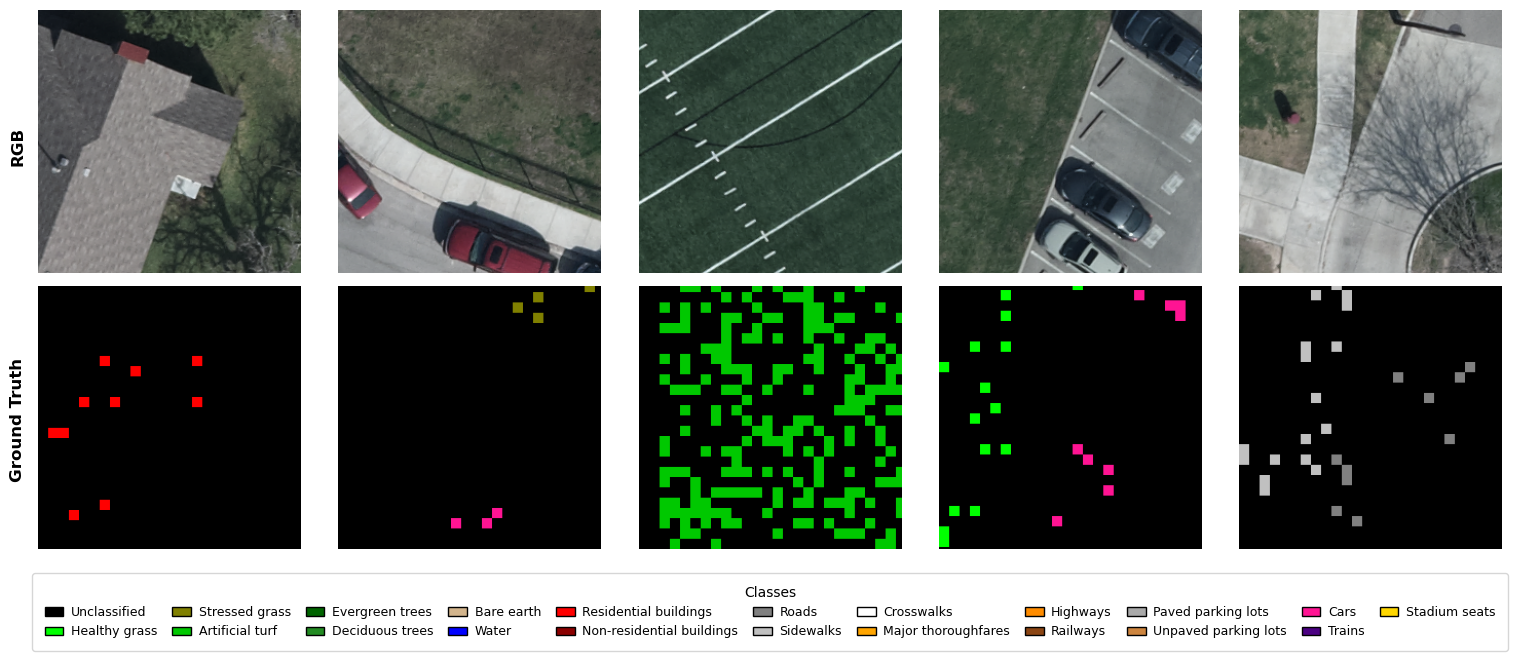

In [20]:
patch_indices = [3,57,1,48,54]  # keep 3,57,1,48,54 | bis 70 geschaut
visualize_rgb_grid(patch_indices, ds, show_gt=True)


**Receptive Field Visuals**

In [ ]:
def compute_receptive_field(model, input_shape=(1, 4, 128, 128), output_pos=(0, 0, 64, 64), visualize=True):
    model.eval()
    x = torch.zeros(input_shape, requires_grad=True)

    # Forward pass
    out = model(x)

    # Create a 1-hot signal at a single output pixel
    mask = torch.zeros_like(out)
    mask[output_pos] = 1.0

    # Backward pass from one output pixel
    out.backward(gradient=mask)

    # Sum absolute gradients over channels to get influence map
    grad_mask = x.grad[0].abs().sum(dim=0)  # shape: (H, W)

    # Compute total receptive field (all non-zero gradients)
    influenced_coords = torch.nonzero(grad_mask > 0, as_tuple=False)
    if len(influenced_coords) == 0:
        rf_size = (0, 0)
    else:
        min_yx = influenced_coords.min(dim=0).values
        max_yx = influenced_coords.max(dim=0).values
        rf_size = (int(max_yx[0] - min_yx[0] + 1), int(max_yx[1] - min_yx[1] + 1))

    # Compute ERF.01
    threshold_01 = 0.01 * grad_mask.max()
    effective_coords_01 = torch.nonzero(grad_mask > threshold_01, as_tuple=False)
    if len(effective_coords_01) == 0:
        erf_01 = (0, 0)
    else:
        min_yx_eff_01 = effective_coords_01.min(dim=0).values
        max_yx_eff_01 = effective_coords_01.max(dim=0).values
        erf_01 = (int(max_yx_eff_01[0] - min_yx_eff_01[0] + 1), int(max_yx_eff_01[1] - min_yx_eff_01[1] + 1))

    # Compute ERF.20
    threshold_20 = 0.20 * grad_mask.max()
    effective_coords_20 = torch.nonzero(grad_mask > threshold_20, as_tuple=False)
    if len(effective_coords_20) == 0:
        erf_20 = (0, 0)
    else:
        min_yx_eff_20 = effective_coords_20.min(dim=0).values
        max_yx_eff_20 = effective_coords_20.max(dim=0).values
        erf_20 = (int(max_yx_eff_20[0] - min_yx_eff_20[0] + 1), int(max_yx_eff_20[1] - min_yx_eff_20[1] + 1))

    # Visualization
    if visualize:
        grad_log = np.log1p(grad_mask.detach().cpu().numpy() * 100)  # scale for visibility
        plt.imshow(grad_log, cmap='hot')
        plt.title('Receptive Field Heatmap')
        plt.colorbar()
        plt.legend()
        plt.show()

    print(f"Receptive field size: {rf_size}")
    print(f"Effective receptive field size (ERF.01): {erf_01}")
    print(f"Effective receptive field size (ERF.20): {erf_20}")

    return rf_size, erf_01, erf_20, grad_mask

C:\Users\Agando\AppData\Local\Temp\ipykernel_16520\1127201317.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


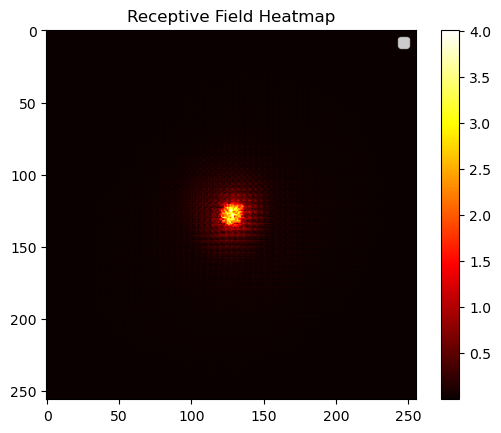

Receptive field size: (256, 256)
Effective receptive field size (ERF.01): (45, 40)
Effective receptive field size (ERF.20): (14, 15)


In [ ]:
model_path = 'trained_models/s1/segmentation/unet_s1_5x5equal.pth'
model = UNet5x5EqualParams(n_channels=2)  # n_channels based on model
model.load_state_dict(torch.load(model_path))
input_shape=(1, 2, 256, 256)
output_pos=(0, 0, 128, 128)
#input_shape=(1, 4, 17, 17)
#output_pos=(0, 0, 9, 9)
rf_size, erf_01, erf_20, grad_mask = compute_receptive_field(model, input_shape, output_pos) # should output of this be symmetric?

In [44]:
def compute_encoder_receptive_fields(encoder, input_shape=(1, 13, 128, 128), visualize=False):
    encoder.eval()
    x = torch.zeros(input_shape, requires_grad=True)

    features = encoder(x)
    results = []

    for i, feat in enumerate(features):
        print(f"Stage {i}: feature shape = {feat.shape}")

        if feat.shape[2] == 0 or feat.shape[3] == 0:
            results.append({'stage': i, 'rf': (0, 0)})
            continue

        grad_mask = torch.zeros_like(feat)
        center_y = feat.shape[2] // 2
        center_x = feat.shape[3] // 2
        grad_mask[0, :, center_y, center_x] = 1.0  # all channels at center pixel

        encoder.zero_grad()
        if x.grad is not None:
            x.grad.zero_()

        try:
            feat.backward(gradient=grad_mask, retain_graph=True)
        except RuntimeError as e:
            print(f"Backward failed at stage {i}: {e}")
            results.append({'stage': i, 'rf': (0, 0)})
            continue

        grad = x.grad[0].abs().sum(dim=0)

        coords = torch.nonzero(grad > 0, as_tuple=False)
        if coords.shape[0] == 0:
            rf = (0, 0)
        else:
            min_yx = coords.min(dim=0).values
            max_yx = coords.max(dim=0).values
            rf = (max_yx - min_yx + 1).tolist()

        if visualize:
            import matplotlib.pyplot as plt
            import numpy as np
            plt.figure()
            plt.imshow(np.log1p(grad.cpu().numpy() * 100), cmap='hot')
            plt.title(f'Stage {i} Receptive Field Heatmap\nRF: {rf}')
            plt.colorbar()
            plt.show()

        results.append({'stage': i, 'rf': rf})

    return results


Stage 0: feature shape = torch.Size([1, 128, 256, 256])


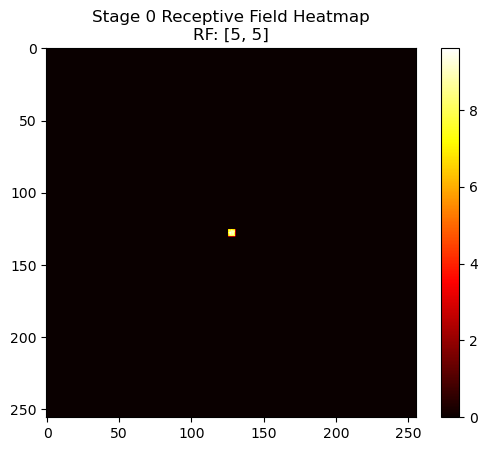

Stage 1: feature shape = torch.Size([1, 128, 128, 128])


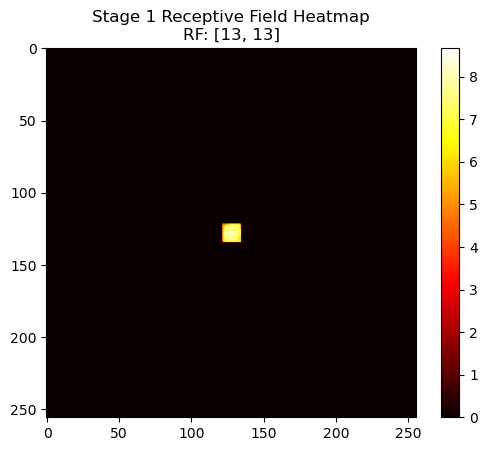

Stage 0: RF = [5, 5]
Stage 1: RF = [13, 13]


In [48]:
model_path = 'trained_models/s1/segmentation/unet_s1_pool1.pth'
model = UNetPool1(n_channels=2)  # n_channels based on model
model.load_state_dict(torch.load(model_path))
encoder = model.encoder
#encoder = EncoderBase(in_channels=13)
rf_info = compute_encoder_receptive_fields(encoder, input_shape=(1, 2, 256, 256), visualize=True)

for r in rf_info:
    print(f"Stage {r['stage']}: RF = {r['rf']}")
